### Feature Correlation

This section uses a covariance matrix to analyze the correlation between features in the dataset.

In [2]:
# Load dataset and configurations
import sys
import os
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.datasets import fetch_openml
from sklearn import metrics
import pandas as pd

# Get df and features from data_ingestion
sys.path.append("../Functions")
sys.path.append("../ThirdParty")
from data_ingestion import get_feature_data
X = get_feature_data()
X = X.iloc[:500]  # use first 500 rows for development

First 5 records:    Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210

In [5]:
# Load cached lyrics and create SBERT embeddings (run once; cached to disk)
from genius import Genius, load_lyrics, save_lyrics
from data_ingestion import data_dir
CACHE_PATH = os.path.join(data_dir, "lyrics_cache_500.pkl")
EMBEDDINGS_PATH = os.path.join(data_dir, "lyric_embeddings_500.pkl")

if os.path.exists(EMBEDDINGS_PATH):
    embeddings = load_lyrics(EMBEDDINGS_PATH)
    print(f"Loaded {len(embeddings)} embeddings from disk")
else:
    cache = load_lyrics(CACHE_PATH)
    client = Genius(os.environ["GENIUS_ACCESS_TOKEN"])  # token required by constructor; embed_text itself is offline
    embeddings = {}
    for key, lyrics in cache.items():
        if lyrics is None:
            continue
        try:
            embeddings[key] = client.embed_text(lyrics)
        except Exception as e:
            print(f"Embed failed for {key}: {e}")
    save_lyrics(embeddings, EMBEDDINGS_PATH)
    print(f"Embedded {len(embeddings)} of {len(cache)} cached songs; saved to {EMBEDDINGS_PATH}")

/Users/yvettesevillano/Documents/software_dev/Spotify-Clusters/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7481.53it/s]


Embedded 410 of 458 cached songs; saved to ../Data/lyric_embeddings_500.pkl


In [15]:
# Extend classification to include lyric embeddings
import numpy as np
from feature_correlation import *
model = client._get_sbert()
similarities = model.similarity(np.float32(list(embeddings.values())), np.float32(list(embeddings.values())))
print(similarities)

tensor([[1.0000, 0.1173, 0.0989,  ..., 0.0836, 0.0537, 0.2287],
        [0.1173, 1.0000, 0.6465,  ..., 0.6995, 0.7255, 0.4156],
        [0.0989, 0.6465, 1.0000,  ..., 0.6804, 0.6071, 0.4457],
        ...,
        [0.0836, 0.6995, 0.6804,  ..., 1.0000, 0.7142, 0.5035],
        [0.0537, 0.7255, 0.6071,  ..., 0.7142, 1.0000, 0.4363],
        [0.2287, 0.4156, 0.4457,  ..., 0.5035, 0.4363, 1.0000]])


In [33]:
import plotly.express as px
size = len(feature_scaling(similarities))
size = 15
keys = list(embeddings.keys())[:size]


fig = px.imshow(similarities)
fig.show()  

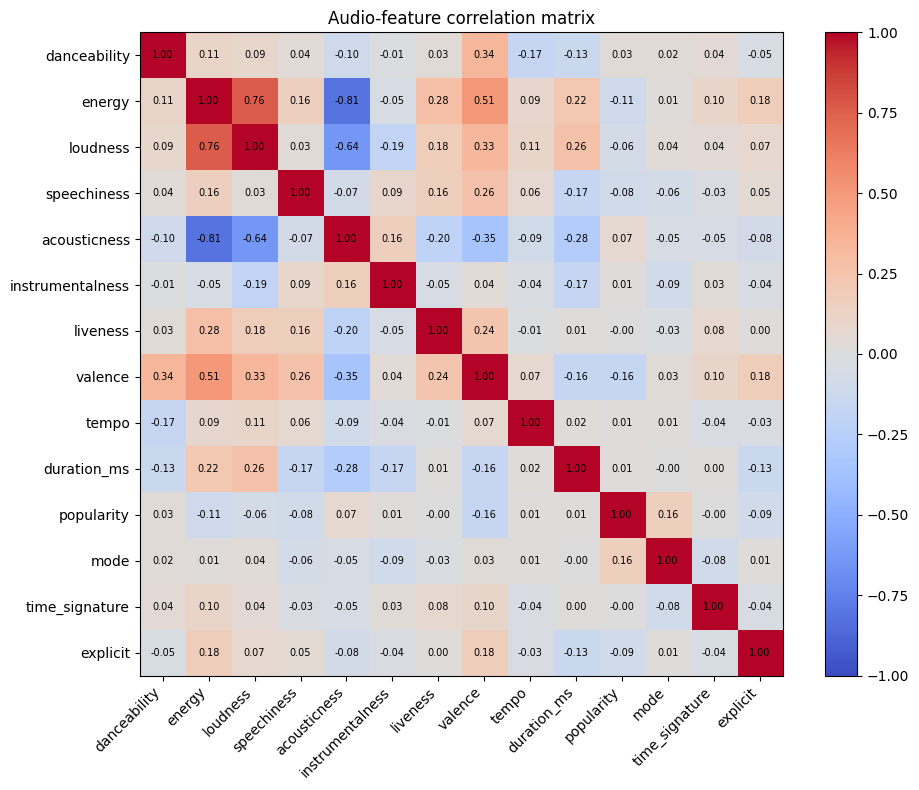

In [32]:
import numpy as np

# Find correlation between audio features
corr = feature_correlation(X)
plot_correlation_matrix(corr)

# Finding the inverse covariance of the scaled features  
VI = inv_cov_matrix(X)

In [ ]:
from umap import UMAP

# Using the covariance matrix to compute the Mahalanobis distance between points
reducer = UMAP(n_components=3,
               n_neighbors=100,
               min_dist=0.1,
               metric="mahalanobis",
               metric_kwds={"VI": VI},
               random_state=42)

X_umap = reducer.fit_transform(feature_scaling(X))
X_umap.shape

In [ ]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "notebook"

fig = px.scatter_3d(
    x=X_umap[:, 0],
    y=X_umap[:, 1],
    z=X_umap[:, 2],
    #color=y_named
)

fig.show()